## **Assignment 1**
You can find the dataset 'BBB.csv' in this folder. It contains the binary labels of blood-brain barrier penetration (1=penetrating, 0=non-penetrating). The blood-brain barrier (BBB) is a selectively permeable barrier that separates the circulating blood from the brain tissue. The BBB plays a crucial role in maintaining the homeostasis of the central nervous system (CNS) by regulating the exchange of substances between the bloodstream and the brain. The BBB also poses a significant challenge to the development of drugs for CNS disorders because it prevents many potentially therapeutic molecules from crossing into the brain.

**Please fill in this notebook with: 
a) python code needed to address the questions reported in the cells below, 
b) DETAILED and COMPREHENSIVE comments for each developed step**
**c) the comments will be crucial for the evaluation of the assignment.**
**d) the code should be executable and the results should be visible in the notebook.**
**e) the final notebook should be organized and clean. The clearness of the code will be taken into account for the final evaluation.**

> **Deadline: 12/03/2025 - 16:00**



### 1) Plot and discuss the distribution of the blood-brain barrier penetration labels in the dataset. Which is the consequence of having such a dataset for a classification task?

In [17]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import MolStandardize
from rdkit.Chem import AllChem  
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger  
RDLogger.DisableLog('rdApp.*')   # Disable rdkit warnings

In [18]:
#check Nan
df_starter = pd.read_csv("BBB_Martins/full_data.csv")
nan_values = df_starter.isna()
print("Number of NaN values per column:")
print(nan_values.sum())

Number of NaN values per column:
Drug_ID    0
smiles     0
label      0
dtype: int64


In [19]:
df_starter

,Drug_ID,smiles,label
0,Propanolol,CC(C)NCC(O)COc1cccc2ccccc12.[Cl],1
1,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
2,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
3,24,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,1
4,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1
...,...,...,...
2025,licostinel,O=c1[nH]c2cc(Cl)c(Cl)c([N+](=O)[O-])c2[nH]c1=O,1
2026,ademetionine(adenosyl-methionine),C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,1
2027,mesocarb,CC(Cc1ccccc1)n1cc([N-]C(=O)Nc2ccccc2)[o+]n1,1
2028,tofisoline,CCc1c(C)[n+]([NH-])c(-c2ccc(OC)c(OC)c2)c2cc(OC...,1


In [20]:
#Clean the database, check for redundancy and remove duplicates
# drop missing values
df_starter = df_starter.dropna(subset=['smiles'])

# Define a function to safely convert SMILES to canonical form
def get_canonical_smiles(smiles):
	mol = Chem.MolFromSmiles(smiles)
	if mol is not None:
		return Chem.MolToSmiles(mol, canonical=True)
	else:
		return None

# Convert SMILES to canonical form and remove duplicates
df_starter['Canonical_SMILES'] = df_starter['smiles'].apply(get_canonical_smiles)
cleaned = df_starter.dropna(subset=['Canonical_SMILES']).drop_duplicates(subset='Canonical_SMILES').drop(columns='Canonical_SMILES')

In [21]:
df=cleaned.copy()
df

,Drug_ID,smiles,label
0,Propanolol,CC(C)NCC(O)COc1cccc2ccccc12.[Cl],1
1,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
2,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
3,24,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,1
4,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1
...,...,...,...
2025,licostinel,O=c1[nH]c2cc(Cl)c(Cl)c([N+](=O)[O-])c2[nH]c1=O,1
2026,ademetionine(adenosyl-methionine),C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,1
2027,mesocarb,CC(Cc1ccccc1)n1cc([N-]C(=O)Nc2ccccc2)[o+]n1,1
2028,tofisoline,CCc1c(C)[n+]([NH-])c(-c2ccc(OC)c(OC)c2)c2cc(OC...,1


In [22]:
nan_values = df.isna()
print("Number of NaN values per column:")
print(nan_values.sum())

Number of NaN values per column:
Drug_ID    0
smiles     0
label      0
dtype: int64


In [23]:
import plotly.express as px
import plotly.graph_objects as go
#with cleaned dataset, extracting feature needed and plotting distribution
p_np_labels = df['label'] # extract the p_pn column

# Count the occurrences of each label
value_counts = p_np_labels.value_counts().reset_index()
value_counts.columns = ['Label', 'Count']
value_counts['Percentage'] = (value_counts['Count'] / value_counts['Count'].sum() * 100).round(2)

# Create labels for the plot
value_counts['Label_text'] = value_counts['Label'].map({0: 'Non-penetrating', 1: 'Penetrating'})

# Create an interactive bar chart with Plotly
fig = px.bar(
    value_counts, 
    x='Label_text', 
    y='Count',
    text=[f"{c} ({p}%)" for c, p in zip(value_counts['Count'], value_counts['Percentage'])],
    color='Label_text',
    color_discrete_map={
        'Non-penetrating': '#FF6B6B', 
        'Penetrating': '#4ECDC4'
    },
    title='Distribution of Blood-Brain Barrier Penetration Labels'
)

# Customize the layout
fig.update_layout(
    xaxis_title='BBB Penetration Label',
    yaxis_title='Frequency',
    showlegend=False,
    hoverlabel=dict(bgcolor="white", font_size=12),
    plot_bgcolor='rgba(240,240,240,0.8)'
)

# Show the plot
fig.show()

# Print distribution statistics for discussion
print(f"Penetrating molecules: {value_counts.loc[value_counts['Label']==1, 'Count'].iloc[0]} ({value_counts.loc[value_counts['Label']==1, 'Percentage'].iloc[0]}%)")
print(f"Non-penetrating molecules: {value_counts.loc[value_counts['Label']==0, 'Count'].iloc[0] if len(value_counts[value_counts['Label']==0]) > 0 else 0} "
      f"({value_counts.loc[value_counts['Label']==0, 'Percentage'].iloc[0] if len(value_counts[value_counts['Label']==0]) > 0 else 0}%)")

Penetrating molecules: 1501 (76.0%)
Non-penetrating molecules: 474 (24.0%)


 Looking at the distribution visualization, we observe a significant class imbalance:
 - Penetrating molecules (76.0%): 1501 instances
 - Non-penetrating molecules (24.0%): 474 instances

 This imbalance has several implications for classification tasks:
 1. Model Bias: Classification algorithms may become biased toward the majority class 
    (penetrating molecules), potentially leading to poor performance in identifying 
    non-penetrating molecules.
 2. Evaluation Metrics: Accuracy would be a misleading metric in this case, as a model 
    always predicting "penetrating" would achieve 76% accuracy without learning any 
    meaningful patterns.
 3. Practical Implications: In drug development, failing to identify non-penetrating 
    molecules (false positives) could lead to wasted resources on compounds that 
    cannot reach the brain.

 Strategies to address this imbalance could include:
 - Resampling techniques: Oversampling the minority class or undersampling the majority class
 - Using weighted loss functions that penalize misclassifications of the minority class more heavily
 - Employing ensemble methods specifically designed for imbalanced data
 - Using evaluation metrics better suited for imbalanced datasets (F1-score, precision-recall AUC, 
   balanced accuracy)

---

### 2) Visualize the chemical space covered by the molecules in the dataset using PCA and t-SNE. Comment and justify the results.


In [24]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from rdkit.Chem import rdFingerprintGenerator
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Generate Morgan fingerprint generator with radius 2 and 2048 bits
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Convert SMILES to RDKit molecule objects
mols = [Chem.MolFromSmiles(smiles) for smiles in df['smiles']]
mols = [mol for mol in mols if mol is not None]  # Filter out None values

# Extract penetration labels for valid molecules
valid_indices = [i for i, mol in enumerate(mols) if mol is not None]
labels = df['label'].iloc[valid_indices].values

# Generate Morgan fingerprints (ECFP) with 2048 bits
print("Generating molecular fingerprints...")
fingerprints = [mfpgen.GetFingerprint(mol) for mol in mols]
fingerprints_array = np.array([list(fp) for fp in fingerprints])

# Apply PCA for dimensionality reduction
print("Applying PCA...")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(fingerprints_array)
print(f"Explained variance ratio with PCA: {pca.explained_variance_ratio_.sum():.2f}")

# Apply t-SNE for dimensionality reduction
print("Applying t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(fingerprints_array)

# Create a dataframe with all the results for easier plotting
viz_df = pd.DataFrame({
    'PCA_1': pca_result[:, 0],
    'PCA_2': pca_result[:, 1],
    'tSNE_1': tsne_result[:, 0],
    'tSNE_2': tsne_result[:, 1],
    'Penetration': labels,
    'PenetrationLabel': ['Penetrating' if l == 1 else 'Non-penetrating' for l in labels],
    'Drug_ID': df['Drug_ID'].iloc[valid_indices].values,
    'SMILES': df['smiles'].iloc[valid_indices].values
})

# Create subplots with 1 row and 2 columns
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        f'PCA Visualization of Chemical Space (Explained Var: {pca.explained_variance_ratio_.sum():.2f})', 
        't-SNE Visualization of Chemical Space'
    ),
    horizontal_spacing=0.1
)

# Add PCA scatter plot
fig.add_trace(
    go.Scatter(
        x=viz_df['PCA_1'],
        y=viz_df['PCA_2'],
        mode='markers',
        marker=dict(
            size=8,
            color=viz_df['Penetration'],
            colorscale='RdBu_r',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="BBB Penetration",
                x=0.45,
                y=0.5,
                thickness=15,
                tickvals=[0, 1],
                ticktext=['Non-penetrating', 'Penetrating']
            ),
            showscale=True
        ),
        text=viz_df['Drug_ID'],
        hoverinfo='text',
        hovertemplate='<b>Name:</b> %{text}<br><b>Penetration:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=1
)

# Add t-SNE scatter plot
fig.add_trace(
    go.Scatter(
        x=viz_df['tSNE_1'],
        y=viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=8,
            color=viz_df['Penetration'],
            colorscale='RdBu_r',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            showscale=False
        ),
        text=viz_df['Drug_ID'],
        hoverinfo='text',
        hovertemplate='<b>Name:</b> %{text}<br><b>Penetration:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    height=700,
    width=1200,
    title_text="Chemical Space Visualization using PCA and t-SNE",
    title_font=dict(size=18),
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
    margin=dict(l=50, r=50, t=100, b=80)
)

# Update x and y axis labels
fig.update_xaxes(title_text=f"Principal Component 1", row=1, col=1)
fig.update_yaxes(title_text=f"Principal Component 2", row=1, col=1)
fig.update_xaxes(title_text=f"t-SNE Component 1", row=1, col=2)
fig.update_yaxes(title_text=f"t-SNE Component 2", row=1, col=2)

# Show the interactive plot
fig.show()

# Add detailed analysis
print("\nAnalysis of Chemical Space Visualization:")
print("------------------------------------------")
print(f"PCA visualization explains {pca.explained_variance_ratio_.sum():.2f} of the total variance, preserving global structure.")
print("t-SNE visualization preserves local neighborhoods and can reveal more detailed clusters.")
print(f"Number of penetrating molecules (1): {sum(labels == 1)} ({sum(labels == 1)/len(labels)*100:.1f}%)")
print(f"Number of non-penetrating molecules (0): {sum(labels == 0)} ({sum(labels == 0)/len(labels)*100:.1f}%)")

# Class distribution in visualized space
print("\nClass Distribution Analysis:")
pca_penetrating = viz_df[viz_df['Penetration'] == 1][['PCA_1', 'PCA_2']]
pca_nonpenetrating = viz_df[viz_df['Penetration'] == 0][['PCA_1', 'PCA_2']]
tsne_penetrating = viz_df[viz_df['Penetration'] == 1][['tSNE_1', 'tSNE_2']]
tsne_nonpenetrating = viz_df[viz_df['Penetration'] == 0][['tSNE_1', 'tSNE_2']]

print(f"PCA - Mean position for penetrating molecules: ({pca_penetrating['PCA_1'].mean():.3f}, {pca_penetrating['PCA_2'].mean():.3f})")
print(f"PCA - Mean position for non-penetrating molecules: ({pca_nonpenetrating['PCA_1'].mean():.3f}, {pca_nonpenetrating['PCA_2'].mean():.3f})")
print(f"t-SNE - Mean position for penetrating molecules: ({tsne_penetrating['tSNE_1'].mean():.3f}, {tsne_penetrating['tSNE_2'].mean():.3f})")
print(f"t-SNE - Mean position for non-penetrating molecules: ({tsne_nonpenetrating['tSNE_1'].mean():.3f}, {tsne_nonpenetrating['tSNE_2'].mean():.3f})")

Generating molecular fingerprints...
Applying PCA...
Explained variance ratio with PCA: 0.08
Applying t-SNE...


c:\Users\miror\Dropbox\SUPSI\Terzo Anno_Secondo Semestre\ACS_Grasso\ACS_GRASSO_venv\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.




Analysis of Chemical Space Visualization:
------------------------------------------
PCA visualization explains 0.08 of the total variance, preserving global structure.
t-SNE visualization preserves local neighborhoods and can reveal more detailed clusters.
Number of penetrating molecules (1): 1501 (76.0%)
Number of non-penetrating molecules (0): 474 (24.0%)

Class Distribution Analysis:
PCA - Mean position for penetrating molecules: (-0.102, -0.270)
PCA - Mean position for non-penetrating molecules: (0.325, 0.857)
t-SNE - Mean position for penetrating molecules: (7.419, -0.681)
t-SNE - Mean position for non-penetrating molecules: (-21.508, 2.955)


### Analysis

#### PCA Visualization:
- **Explained Variance**: The PCA visualization explains 8% of the total variance in the dataset. This indicates that while PCA captures some of the global structure of the data, it does not account for most of the variance. This is typical in high-dimensional chemical datasets where a few principal components cannot capture all the complexity.
- **Class Distribution**: 
    - The mean positions suggest that penetrating and non-penetrating molecules are somewhat separated in the PCA space, but there is still significant overlap. This overlap indicates that PCA alone may not be sufficient to distinguish between the two classes effectively.

#### t-SNE Visualization:
- **Local Neighborhoods**: t-SNE is effective in preserving local neighborhoods, which means it can reveal more detailed clusters and relationships between molecules that are similar in their high-dimensional space.
- **Class Distribution**:
    - The t-SNE visualization shows a more distinct separation between penetrating and non-penetrating molecules in local clusters compared to PCA. This suggests that t-SNE is better at capturing the local structure and differences between the two classes.

#### Justification:
- **PCA**: While PCA is useful for reducing dimensionality and capturing global structure, it may not be the best choice for datasets with complex, non-linear relationships like chemical datasets. The explained variance of 8% indicates that much of the data's complexity is not captured by the first two principal components.
- **t-SNE**: t-SNE excels in visualizing high-dimensional data by preserving local neighborhoods, making it more suitable for identifying clusters and patterns that are not apparent in PCA. The distinct local cluster separation in t-SNE plots suggests that it can better differentiate between penetrating and non-penetrating molecules that are grouped togheter.

---

### 3) Plot the distribution of interpretable physicochemical properties like molecular weight, LogP, molecular_volume, number of rotable bonds and others in the dataset and discuss how these properties are distributed between the two classes. Is there any property that is able to distinguish active (permeable) against non-active (non-permeable) molecules? Discuss the results.


In [25]:
from rdkit.Chem import Descriptors, Lipinski, MolSurf

# Calculate and analyze physicochemical properties

# Function to calculate molecular properties
def calculate_properties(mol):
    if mol is None:
        return None
    
    properties = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'TPSA': MolSurf.TPSA(mol),
        'Rotatable_Bonds': Descriptors.NumRotatableBonds(mol),
        'Aromatic_Rings': Descriptors.NumAromaticRings(mol),
        'Heavy_Atoms': mol.GetNumHeavyAtoms(),
        'Fraction_CSP3': Descriptors.FractionCSP3(mol),  # Fraction of SP3 carbons
        'QED': Descriptors.qed(mol)  # Drug-likeness score
    }
    return properties

# Calculate properties for all molecules
print("Calculating molecular properties...")
properties_list = []
for i, mol in enumerate(mols):
    props = calculate_properties(mol)
    if props is not None:
        props['label'] = df['label'].iloc[valid_indices[i]]
        properties_list.append(props)

# Create dataframe with properties
prop_df = pd.DataFrame(properties_list)

# Add class labels for easier plotting
prop_df['Class'] = prop_df['label'].map({1: 'Penetrating', 0: 'Non-penetrating'})

# Create subplots with 3x3 grid for main properties
fig = make_subplots(rows=3, cols=3, 
                   subplot_titles=('Molecular Weight', 'LogP', 'Hydrogen Bond Donors', 
                                  'Hydrogen Bond Acceptors', 'Topological PSA', 'Rotatable Bonds',
                                  'Aromatic Rings', 'Heavy Atoms', 'Fraction CSP3'))

# Define properties to plot and their positions
properties = [
    {'Drug_ID': 'MW', 'row': 1, 'col': 1, 'title': 'Molecular Weight (Da)'},
    {'Drug_ID': 'LogP', 'row': 1, 'col': 2, 'title': 'LogP (Lipophilicity)'},
    {'Drug_ID': 'HBD', 'row': 1, 'col': 3, 'title': 'Hydrogen Bond Donors'},
    {'Drug_ID': 'HBA', 'row': 2, 'col': 1, 'title': 'Hydrogen Bond Acceptors'},
    {'Drug_ID': 'TPSA', 'row': 2, 'col': 2, 'title': 'Topological PSA (Å²)'},
    {'Drug_ID': 'Rotatable_Bonds', 'row': 2, 'col': 3, 'title': 'Rotatable Bonds'},
    {'Drug_ID': 'Aromatic_Rings', 'row': 3, 'col': 1, 'title': 'Aromatic Rings'},
    {'Drug_ID': 'Heavy_Atoms', 'row': 3, 'col': 2, 'title': 'Heavy Atoms'},
    {'Drug_ID': 'Fraction_CSP3', 'row': 3, 'col': 3, 'title': 'Fraction CSP3'}
]

# Colors for the two classes
colors = {'Penetrating': '#4ECDC4', 'Non-penetrating': '#FF6B6B'}

# Add density plots for each property
for prop in properties:
    for cls in ['Penetrating', 'Non-penetrating']:
        data = prop_df[prop_df['Class'] == cls][prop['Drug_ID']]
        
        fig.add_trace(
            go.Violin(
                x=data,
                name=cls,
                line_color=colors[cls],
                side='positive',
                meanline_visible=True,
                showlegend=True if (prop['row'] == 1 and prop['col'] == 1) else False,
                legendgroup=cls,
                scalemode='width',
                width=2,
                points=False
            ),
            row=prop['row'], col=prop['col']
        )

# Update layout for larger plots and better appearance
fig.update_layout(
    height=1200,  # Increased height
    width=1500,   # Increased width
    title_text="Distribution of Physicochemical Properties for BBB Penetrating vs. Non-penetrating Molecules",
    title_font_size=20,
    legend_title="BBB Penetration",
    template="plotly_white",
    violinmode='overlay'  # This ensures violins are overlaid rather than side by side
)

# Add annotations explaining the significance of each property, now positioned below each subplot
annotations = [
    dict(x=0.16, y=0.65, text="Low MW (<400) favors BBB penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.5, y=0.65, text="Optimal LogP (1-4) improves penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.85, y=0.65, text="Fewer H-bond donors enhance BBB crossing", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.16, y=0.30, text="Fewer acceptors improve penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.5, y=0.30, text="Lower TPSA (<70 Å²) favors penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.85, y=0.30, text="Fewer rotatable bonds enhance BBB passage", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.16, y=-0.07, text="Aromatic rings can affect penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.5, y=-0.07, text="Smaller molecules cross BBB more easily", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.85, y=-0.07, text="Higher sp3 fraction can improve properties", showarrow=False, xref="paper", yref="paper")
]

fig.update_layout(annotations=annotations)

# Update axes for better appearance
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

for prop in properties:
    fig.update_yaxes(title_text="Density", row=prop['row'], col=prop['col'])
    fig.update_xaxes(title_text=prop['title'], row=prop['row'], col=prop['col'])

# Add a QED plot separately
fig_qed = px.violin(prop_df, x="QED", color="Class", 
                    box=True, points=False,
                    color_discrete_map=colors,
                    labels={"QED": "Quantitative Estimation of Drug-likeness"},
                    title="Distribution of Drug-likeness (QED) Score")

fig_qed.update_layout(template="plotly_white", legend_title="BBB Penetration", violinmode='overlay')

# Show the plots
fig.show()
fig_qed.show()

# Statistical analysis to determine whether properties can distinguish between classes
print("\nStatistical Summary of Properties by Class:")
penetrating = prop_df[prop_df['Class'] == 'Penetrating']
non_penetrating = prop_df[prop_df['Class'] == 'Non-penetrating']

summary_stats = pd.DataFrame({
    'Property': [p['Drug_ID'] for p in properties] + ['QED'],
    'Penetrating_Mean': [penetrating[p['Drug_ID']].mean() for p in properties] + [penetrating['QED'].mean()],
    'Non_Penetrating_Mean': [non_penetrating[p['Drug_ID']].mean() for p in properties] + [non_penetrating['QED'].mean()],
    'Difference': [penetrating[p['Drug_ID']].mean() - non_penetrating[p['Drug_ID']].mean() for p in properties] + 
                  [penetrating['QED'].mean() - non_penetrating['QED'].mean()],
    'Percent_Difference': [100 * (penetrating[p['Drug_ID']].mean() - non_penetrating[p['Drug_ID']].mean()) / 
                          non_penetrating[p['Drug_ID']].mean() for p in properties] + 
                          [100 * (penetrating['QED'].mean() - non_penetrating['QED'].mean()) / 
                           non_penetrating['QED'].mean()]
})

print(summary_stats.sort_values(by='Percent_Difference', ascending=False).round(3))

Calculating molecular properties...



Statistical Summary of Properties by Class:
          Property  Penetrating_Mean  Non_Penetrating_Mean  Difference  \
1             LogP             2.668                 1.149       1.519   
9              QED             0.674                 0.458       0.216   
6   Aromatic_Rings             1.404                 1.414      -0.009   
8    Fraction_CSP3             0.461                 0.472      -0.011   
7      Heavy_Atoms            22.262                30.338      -8.076   
0               MW           317.604               439.011    -121.406   
5  Rotatable_Bonds             3.810                 5.458      -1.648   
3              HBA             3.754                 7.367      -3.613   
4             TPSA            54.120               127.156     -73.035   
2              HBD             1.058                 3.177      -2.119   

   Percent_Difference  
1             132.170  
9              47.117  
6              -0.644  
8              -2.256  
7             -26.62

### **Descriptor Analysis & Interpretation:**

1. **Molecular Weight (MW)**
   - **Observation**: BBB-penetrating molecules have a lower average MW (~318 Da) compared to non-penetrating ones (~440 Da).
   - **Interpretation**: Lower molecular weight favors permeability, as smaller molecules diffuse more easily through the blood-brain barrier (BBB). Larger molecules tend to have poor penetration.

2. **LogP (Lipophilicity)**
   - **Observation**: LogP is significantly higher in penetrating molecules (~2.67) than in non-penetrating ones (~1.15).
   - **Interpretation**: Lipophilicity plays a crucial role in BBB permeability. A moderate LogP (typically between 1-4) enhances penetration by promoting passive diffusion across lipid membranes.

3. **Hydrogen Bond Donors (HBD)**
   - **Observation**: BBB-penetrating molecules have significantly fewer HBDs (~1.06) compared to non-penetrating ones (~3.18).
   - **Interpretation**: Fewer hydrogen bond donors reduce interactions with aqueous environments, improving lipophilic character and passive diffusion.

4. **Hydrogen Bond Acceptors (HBA)**
   - **Observation**: Penetrating molecules have fewer HBAs (~3.75) than non-penetrating ones (~7.37).
   - **Interpretation**: Similar to HBD, fewer HBAs reduce water affinity, increasing lipophilicity and improving BBB penetration.

5. **Topological Polar Surface Area (TPSA)**
   - **Observation**: TPSA is lower in BBB-penetrating molecules (~54 Å²) compared to non-penetrating (~127 Å²).
   - **Interpretation**: A lower TPSA (<70 Å²) is favorable for BBB penetration as it reduces hydrophilicity and improves lipid solubility.

6. **Rotatable Bonds**
   - **Observation**: Penetrating molecules have fewer rotatable bonds (~3.81) compared to non-penetrating (~5.46).
   - **Interpretation**: Reduced molecular flexibility enhances passive diffusion by maintaining a compact conformation suitable for membrane permeability.

7. **Heavy Atoms**
   - **Observation**: Penetrating molecules contain fewer heavy atoms (~22.26) than non-penetrating molecules (~30.34).
   - **Interpretation**: Smaller molecular structures, with fewer heavy atoms, correlate with higher BBB penetration.

8. **Aromatic Rings**
   - **Observation**: No significant difference (~1.40 in permeable vs. ~1.41 in non-permeable).
   - **Interpretation**: The number of aromatic rings alone does not significantly impact permeability.

9. **Fraction of sp3 Carbon (Fraction_CSP3)**
   - **Observation**: No strong difference (~0.461 vs. ~0.472).
   - **Interpretation**: While sp3 hybridization affects 3D conformation, it does not seem to distinguish permeability significantly.

10. **QED (Quantitative Estimate of Drug-likeness)**
    - **Observation**: Higher QED in penetrating molecules (~0.67) than in non-penetrating (~0.46).
    - **Interpretation**: Higher QED suggests that BBB-penetrating molecules tend to have more drug-like properties, balancing lipophilicity and molecular weight.

### **Key Insights & Conclusions:**
- **Distinguishing Properties**:
  - **Most Distinguishing**: LogP, MW, HBD, HBA, TPSA.
  - **Less Significant**: Aromatic rings, Fraction_CSP3.
- **Ideal BBB-Penetration Profile**:
  - **MW**: <400 Da
  - **LogP**: Between 1-4
  - **TPSA**: <70 Å²
  - **HBD & HBA**: Low count (<2 HBD, <5 HBA)
  - **Rotatable Bonds**: Fewer for rigidity

I've taken many of the considerations written above from internet and various scientific sources, since i'm not an expert in BBB-penetrating molecules

In [26]:
prop_df.drop(columns=['label', 'Class'], inplace=True)
prop_df

,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,Heavy_Atoms,Fraction_CSP3,QED
0,294.802,3.26700,2,3,41.49,6,2,20,0.375000,0.859050
1,360.325,4.63500,0,3,29.54,9,1,23,0.611111,0.474821
2,361.373,1.54400,1,6,75.01,2,2,26,0.444444,0.874740
3,290.407,2.57750,1,3,41.57,7,1,21,0.588235,0.784810
4,435.889,2.54872,2,6,112.74,4,2,29,0.368421,0.709265
...,...,...,...,...,...,...,...,...,...,...
1970,276.035,1.43140,2,4,108.86,1,2,17,0.000000,0.466075
1971,398.445,-3.25690,4,11,185.46,7,2,27,0.600000,0.344970
1972,322.368,4.79820,1,3,72.32,5,3,24,0.166667,0.685827
1973,382.460,4.51482,0,4,64.60,6,3,28,0.318182,0.588327


In [28]:
#combine df and prop_df on index
df = df.reset_index(drop=True)
prop_df = prop_df.reset_index(drop=True)
df = pd.concat([df, prop_df], axis=1)
df

,Drug_ID,smiles,label,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,...,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,Heavy_Atoms,Fraction_CSP3,QED
0,Propanolol,CC(C)NCC(O)COc1cccc2ccccc12.[Cl],1,294.802,3.26700,2,3,41.49,6,2,...,294.802,3.26700,2,3,41.49,6,2,20,0.375000,0.859050
1,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1,360.325,4.63500,0,3,29.54,9,1,...,360.325,4.63500,0,3,29.54,9,1,23,0.611111,0.474821
2,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1,361.373,1.54400,1,6,75.01,2,2,...,361.373,1.54400,1,6,75.01,2,2,26,0.444444,0.874740
3,24,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,1,290.407,2.57750,1,3,41.57,7,1,...,290.407,2.57750,1,3,41.57,7,1,21,0.588235,0.784810
4,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1,435.889,2.54872,2,6,112.74,4,2,...,435.889,2.54872,2,6,112.74,4,2,29,0.368421,0.709265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,licostinel,O=c1[nH]c2cc(Cl)c(Cl)c([N+](=O)[O-])c2[nH]c1=O,1,276.035,1.43140,2,4,108.86,1,2,...,276.035,1.43140,2,4,108.86,1,2,17,0.000000,0.466075
1971,ademetionine(adenosyl-methionine),C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,1,398.445,-3.25690,4,11,185.46,7,2,...,398.445,-3.25690,4,11,185.46,7,2,27,0.600000,0.344970
1972,mesocarb,CC(Cc1ccccc1)n1cc([N-]C(=O)Nc2ccccc2)[o+]n1,1,322.368,4.79820,1,3,72.32,5,3,...,322.368,4.79820,1,3,72.32,5,3,24,0.166667,0.685827
1973,tofisoline,CCc1c(C)[n+]([NH-])c(-c2ccc(OC)c(OC)c2)c2cc(OC...,1,382.460,4.51482,0,4,64.60,6,3,...,382.460,4.51482,0,4,64.60,6,3,28,0.318182,0.588327


---

### 4) Select the best algorithm and chemical fingerprint to clusterize molecules in the dataset. Is there any algorithm which is able to correctly distinguish active (permeable) against non-active (non-permeable) molecules? Please deeply discuss the results.

Generating different types of molecular fingerprints...

Calculating Tanimoto similarity matrices...

Tanimoto Similarity Statistics:
           Fingerprint  Penetrating Internal Similarity  \
0       Morgan (ECFP4)                         0.106413   
1           MACCS Keys                         0.332452   
2             AtomPair                         0.187476   
3  Topological Torsion                         0.075884   
4                RDKit                         0.215259   

   Non-penetrating Internal Similarity  Between-Class Similarity  Pen-Pen Std  \
0                             0.114401                  0.097807     0.059986   
1                             0.393770                  0.332304     0.146963   
2                             0.212770                  0.175749     0.101329   
3                             0.081304                  0.061489     0.079197   
4                             0.314275                  0.245329     0.117295   

   NonPen-NonPen Std  Be


Cluster Analysis for RDKit with Agglomerative:
Cluster 0 is primarily Penetrating (82.4% pure)
Cluster 1 is primarily Non-penetrating (68.7% pure)
Overall weighted purity: 80.7%

Cluster Distribution:
                  | Penetrating | Non-penetrating | Total
------------------+-------------+----------------+------
Cluster 0         |        1423 |            303 |  1726
Cluster 1         |          78 |            171 |   249
------------------+-------------+----------------+------
Total             |        1501 |            474 |  1975

Detailed Discussion of Results:
------------------------------
1. Best Fingerprint: RDKit
2. Best Algorithm: Agglomerative
3. Adjusted Rand Index (similarity to ground truth): 0.266
4. Silhouette Score (cluster quality): 0.147
5. Davies-Bouldin Index (lower is better): 2.106

6. Tanimoto Similarity Analysis for Best Fingerprint:
   - Internal similarity among penetrating compounds: 0.215 ± 0.117
   - Internal similarity among non-penetrating compound

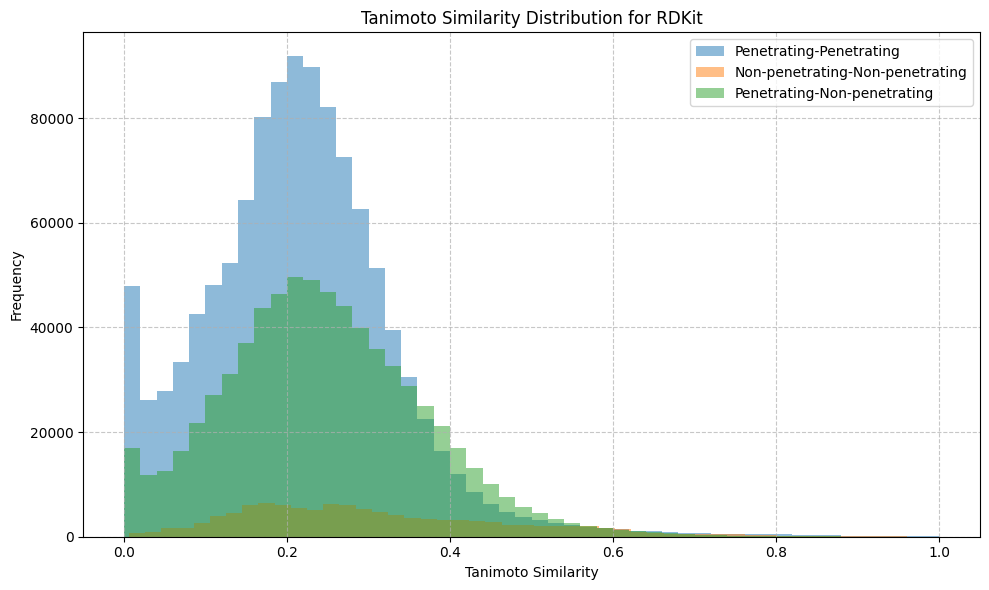

In [29]:
from rdkit.Chem import rdMolDescriptors, AllChem, rdFingerprintGenerator
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score as adjusted_rand_index
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from plotly.subplots import make_subplots
from rdkit import DataStructs  # For Tanimoto similarity calculation
import matplotlib.pyplot as plt
import plotly.graph_objects as go
# Add import for Self-Organizing Maps
from minisom import MiniSom

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
rdkgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
apgen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
ttgen = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=2048)

# Generate different types of fingerprints
print("Generating different types of molecular fingerprints...")
fingerprint_types = {
    'Morgan (ECFP4)': [],
    'MACCS Keys': [],
    'AtomPair': [],
    'Topological Torsion': [],
    'RDKit': []
}

# Store original fingerprint objects for Tanimoto calculation
original_fingerprints = {
    'Morgan (ECFP4)': [],
    'MACCS Keys': [],
    'AtomPair': [],
    'Topological Torsion': [],
    'RDKit': []
}

for mol in mols:
    if mol is not None:
        # Morgan/ECFP4 fingerprint (radius 2 corresponds to ECFP4)
        morgan_fp = mfpgen.GetFingerprint(mol)
        fingerprint_types['Morgan (ECFP4)'].append(np.array(morgan_fp))
        original_fingerprints['Morgan (ECFP4)'].append(morgan_fp)
        
        # MACCS Keys (166 bits)
        maccs_fp = rdMolDescriptors.GetMACCSKeysFingerprint(mol)
        fingerprint_types['MACCS Keys'].append(np.array(maccs_fp))
        original_fingerprints['MACCS Keys'].append(maccs_fp)
        
        # Atom Pair fingerprint
        ap_fp = apgen.GetFingerprint(mol)
        fingerprint_types['AtomPair'].append(np.array(ap_fp))
        original_fingerprints['AtomPair'].append(ap_fp)
        
        # Topological Torsion fingerprint
        tt_fp = ttgen.GetFingerprint(mol)
        fingerprint_types['Topological Torsion'].append(np.array(tt_fp))
        original_fingerprints['Topological Torsion'].append(tt_fp)
        
        # RDKit fingerprint
        rdkit_fp = rdkgen.GetFingerprint(mol)
        fingerprint_types['RDKit'].append(np.array(rdkit_fp))
        original_fingerprints['RDKit'].append(rdkit_fp)

# Convert lists to numpy arrays
for fp_type in fingerprint_types:
    fingerprint_types[fp_type] = np.array(fingerprint_types[fp_type])

# Calculate Tanimoto similarity matrices for each fingerprint type
print("\nCalculating Tanimoto similarity matrices...")
tanimoto_matrices = {}
tanimoto_stats = {}

for fp_name, fp_list in original_fingerprints.items():
    n = len(fp_list)
    tanimoto_matrix = np.zeros((n, n))
    
    # Calculate all pairwise Tanimoto similarities
    for i in range(n):
        for j in range(i, n):
            sim = DataStructs.TanimotoSimilarity(fp_list[i], fp_list[j])
            tanimoto_matrix[i, j] = sim
            tanimoto_matrix[j, i] = sim
    
    tanimoto_matrices[fp_name] = tanimoto_matrix
    
    # Calculate similarity statistics between penetrating and non-penetrating compounds
    penetrating_indices = [i for i, label in enumerate(labels) if label == 1]
    nonpenetrating_indices = [i for i, label in enumerate(labels) if label == 0]
    
    # Within-class similarities
    pen_pen_sims = [tanimoto_matrix[i, j] for i in penetrating_indices for j in penetrating_indices if i < j]
    nonpen_nonpen_sims = [tanimoto_matrix[i, j] for i in nonpenetrating_indices for j in nonpenetrating_indices if i < j]
    
    # Between-class similarities
    pen_nonpen_sims = [tanimoto_matrix[i, j] for i in penetrating_indices for j in nonpenetrating_indices]
    
    tanimoto_stats[fp_name] = {
        'penetrating_internal_similarity': np.mean(pen_pen_sims),
        'nonpenetrating_internal_similarity': np.mean(nonpen_nonpen_sims),
        'between_class_similarity': np.mean(pen_nonpen_sims),
        'pen_pen_std': np.std(pen_pen_sims),
        'nonpen_nonpen_std': np.std(nonpen_nonpen_sims),
        'between_class_std': np.std(pen_nonpen_sims)
    }

# Report Tanimoto similarity statistics
print("\nTanimoto Similarity Statistics:")
tanimoto_df = pd.DataFrame({
    'Fingerprint': [],
    'Penetrating Internal Similarity': [],
    'Non-penetrating Internal Similarity': [],
    'Between-Class Similarity': [],
    'Pen-Pen Std': [],
    'NonPen-NonPen Std': [],
    'Between-Class Std': []
})

for fp_name, stats in tanimoto_stats.items():
    tanimoto_df = pd.concat([tanimoto_df, pd.DataFrame({
        'Fingerprint': [fp_name],
        'Penetrating Internal Similarity': [stats['penetrating_internal_similarity']],
        'Non-penetrating Internal Similarity': [stats['nonpenetrating_internal_similarity']],
        'Between-Class Similarity': [stats['between_class_similarity']],
        'Pen-Pen Std': [stats['pen_pen_std']],
        'NonPen-NonPen Std': [stats['nonpen_nonpen_std']],
        'Between-Class Std': [stats['between_class_std']]
    })], ignore_index=True)

print(tanimoto_df)

# Define clustering algorithms to test
clustering_algorithms = {
    'KMeans': KMeans(n_clusters=2, random_state=42, n_init=10),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=2),
    'SOM': 'SOM'  # Placeholder for SOM that will be initialized for each fingerprint
}

# Evaluate each fingerprint type with each clustering algorithm
results = []

for fp_name, fp_data in fingerprint_types.items():
    for alg_name, algorithm in clustering_algorithms.items():
        # Skip DBSCAN for high dimensional data as it performs poorly
        if alg_name == 'DBSCAN' and fp_data.shape[1] > 500:
            continue
            
        print(f"Evaluating {alg_name} with {fp_name}...")
        
        try:
            # Special handling for SOM
            if alg_name == 'SOM':
                # Initialize SOM (map size can be adjusted)
                som_dim = int(np.sqrt(2 * np.sqrt(len(fp_data))))  # Heuristic for map size
                som = MiniSom(x=som_dim, y=som_dim, input_len=fp_data.shape[1], 
                             sigma=1.0, learning_rate=0.5, 
                             random_seed=42)
                
                # Normalize the data
                data_scaled = StandardScaler().fit_transform(fp_data)
                
                # Train the SOM
                som.train(data_scaled, 1000, verbose=False)
                
                # Get the cluster assignments (based on BMU)
                cluster_labels = np.zeros(len(fp_data))
                for i, x in enumerate(data_scaled):
                    winner = som.winner(x)
                    # Convert 2D winner coordinates to 1D cluster label
                    cluster_labels[i] = winner[0] * som_dim + winner[1]
                
                # Reduce to 2 clusters using KMeans to make it comparable 
                # to other methods and for easier evaluation
                kmeans_post = KMeans(n_clusters=2, random_state=42)
                unique_labels = np.unique(cluster_labels)
                if len(unique_labels) > 2:
                    # Create centroid map and cluster the map
                    centroids = np.array([np.mean(data_scaled[cluster_labels == label], axis=0) 
                                        for label in unique_labels])
                    kmeans_post.fit(centroids)
                    # Map original cluster labels to 2 clusters
                    label_mapping = kmeans_post.labels_
                    cluster_labels_2 = np.zeros_like(cluster_labels)
                    for i, label in enumerate(cluster_labels):
                        idx = np.where(unique_labels == label)[0][0]
                        cluster_labels_2[i] = label_mapping[idx]
                    cluster_labels = cluster_labels_2
            else:
                # Fit the regular clustering algorithm
                cluster_labels = algorithm.fit_predict(fp_data)
            
            # Calculate metrics
            try:
                sil_score = silhouette_score(fp_data, cluster_labels)
                ari_score = adjusted_rand_index(labels, cluster_labels)
                dbi_score = davies_bouldin_score(fp_data, cluster_labels)
            except:
                # Handle case with only one cluster or other issues
                sil_score = -1
                ari_score = -1
                dbi_score = float('inf')
            
            # Cluster distribution analysis
            unique_labels = np.unique(cluster_labels)
            if len(unique_labels) >= 2:
                # Map to 0 and 1 for consistency
                cluster_0 = unique_labels[0]
                cluster_1 = unique_labels[1]
                
                cluster_0_penetrating = np.sum((cluster_labels == cluster_0) & (labels == 1))
                cluster_0_nonpenetrating = np.sum((cluster_labels == cluster_0) & (labels == 0))
                cluster_1_penetrating = np.sum((cluster_labels == cluster_1) & (labels == 1))
                cluster_1_nonpenetrating = np.sum((cluster_labels == cluster_1) & (labels == 0))
            else:
                # Handle case with only one cluster
                cluster_0_penetrating = np.sum(labels == 1)
                cluster_0_nonpenetrating = np.sum(labels == 0)
                cluster_1_penetrating = 0
                cluster_1_nonpenetrating = 0
            
            # Calculate purity
            total_cluster_0 = cluster_0_penetrating + cluster_0_nonpenetrating
            total_cluster_1 = cluster_1_penetrating + cluster_1_nonpenetrating
            
            if total_cluster_0 > 0:
                purity_cluster_0 = max(cluster_0_penetrating, cluster_0_nonpenetrating) / total_cluster_0
            else:
                purity_cluster_0 = 0
                
            if total_cluster_1 > 0:
                purity_cluster_1 = max(cluster_1_penetrating, cluster_1_nonpenetrating) / total_cluster_1
            else:
                purity_cluster_1 = 0
            
            # Calculate weighted average purity
            total_points = total_cluster_0 + total_cluster_1
            weighted_purity = (purity_cluster_0 * total_cluster_0 + purity_cluster_1 * total_cluster_1) / total_points
            
            # Append the results
            results.append({
                'Fingerprint': fp_name,
                'Algorithm': alg_name,
                'Silhouette': sil_score,
                'ARI': ari_score,
                'DBI': dbi_score,
                'Cluster0_Penetrating': cluster_0_penetrating,
                'Cluster0_NonPenetrating': cluster_0_nonpenetrating,
                'Cluster1_Penetrating': cluster_1_penetrating,
                'Cluster1_NonPenetrating': cluster_1_nonpenetrating,
                'Purity_Cluster0': purity_cluster_0,
                'Purity_Cluster1': purity_cluster_1,
                'Weighted_Purity': weighted_purity
            })
            
        except Exception as e:
            print(f"Error with {alg_name} on {fp_name}: {str(e)}")
            continue

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\nFingerprint and Algorithm Evaluation Results:")
print(results_df.sort_values('Weighted_Purity', ascending=False).head(10))

# Plot the top 3 combinations
best_combinations = results_df.sort_values('Weighted_Purity', ascending=False).head(3)
best_fp_alg = best_combinations.iloc[0]
best_fp_name = best_fp_alg['Fingerprint']
best_alg_name = best_fp_alg['Algorithm']

# Get the best fingerprint data and rerun the best algorithm
best_fp_data = fingerprint_types[best_fp_name]

# Special handling for SOM if it's the best
if best_alg_name == 'SOM':
    # Initialize and train SOM again
    som_dim = int(np.sqrt(2 * np.sqrt(len(best_fp_data))))
    som = MiniSom(x=som_dim, y=som_dim, input_len=best_fp_data.shape[1], 
                 sigma=1.0, learning_rate=0.5, 
                 random_seed=42)
    data_scaled = StandardScaler().fit_transform(best_fp_data)
    som.train(data_scaled, 1000, verbose=False)
    
    # Get BMUs and reduce to 2 clusters
    best_clusters = np.zeros(len(best_fp_data))
    for i, x in enumerate(data_scaled):
        winner = som.winner(x)
        best_clusters[i] = winner[0] * som_dim + winner[1]
    
    # Reduce to 2 clusters
    unique_labels = np.unique(best_clusters)
    if len(unique_labels) > 2:
        centroids = np.array([np.mean(data_scaled[best_clusters == label], axis=0) 
                            for label in unique_labels])
        kmeans_post = KMeans(n_clusters=2, random_state=42)
        kmeans_post.fit(centroids)
        label_mapping = kmeans_post.labels_
        best_clusters_2 = np.zeros_like(best_clusters)
        for i, label in enumerate(best_clusters):
            idx = np.where(unique_labels == label)[0][0]
            best_clusters_2[i] = label_mapping[idx]
        best_clusters = best_clusters_2
else:
    # Use the regular algorithm
    best_algorithm = clustering_algorithms[best_alg_name]
    best_clusters = best_algorithm.fit_predict(best_fp_data)

# Rest of the visualization code remains the same
print(f"\nVisualizing the best combination: {best_fp_name} with {best_alg_name}")

# Create a DataFrame for visualization
cluster_viz_df = pd.DataFrame({
    'tSNE_1': viz_df['tSNE_1'],
    'tSNE_2': viz_df['tSNE_2'],
    'Actual_Class': viz_df['PenetrationLabel'],
    'Predicted_Cluster': ["Cluster " + str(c) for c in best_clusters],
    'Drug_ID': viz_df['Drug_ID']
})

# Create subplots with 1 row and 2 columns
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Actual BBB Penetration Classes', 
        f'Predicted Clusters using {best_fp_name} with {best_alg_name}'
    ),
    horizontal_spacing=0.1
)

# Add actual classes scatter plot
fig.add_trace(
    go.Scatter(
        x=cluster_viz_df['tSNE_1'],
        y=cluster_viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=8,
            color=viz_df['Penetration'],
            colorscale='RdBu_r',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="BBB Penetration",
                x=0.45,
                y=0.5,
                thickness=15,
                tickvals=[0, 1],
                ticktext=['Non-penetrating', 'Penetrating']
            ),
            showscale=True
        ),
        text=cluster_viz_df['Drug_ID'],
        hovertemplate='<b>Name:</b> %{text}<br><b>Actual Class:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=1
)

# Add predicted clusters scatter plot
fig.add_trace(
    go.Scatter(
        x=cluster_viz_df['tSNE_1'],
        y=cluster_viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=8,
            color=best_clusters,
            colorscale='Viridis',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="Predicted Cluster",
                x=1.0,
                y=0.5,
                thickness=15,
                tickvals=[0, 1],
                ticktext=['Cluster 0', 'Cluster 1']
            ),
            showscale=True
        ),
        text=cluster_viz_df['Drug_ID'],
        hovertemplate='<b>Name:</b> %{text}<br><b>Predicted Cluster:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    height=600,
    width=1200,
    title_text=f"BBB Penetration Clustering: Actual Classes vs. Predicted Clusters",
    title_font=dict(size=18),
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
    margin=dict(l=50, r=50, t=100, b=80)
)

# Update axis labels
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=1)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=1)
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=2)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=2)

# Show the interactive plot
fig.show()

# Analyze confusion matrix for the best combination
cluster0_majority = "Penetrating" if best_fp_alg['Cluster0_Penetrating'] > best_fp_alg['Cluster0_NonPenetrating'] else "Non-penetrating"
cluster1_majority = "Penetrating" if best_fp_alg['Cluster1_Penetrating'] > best_fp_alg['Cluster1_NonPenetrating'] else "Non-penetrating"

print(f"\nCluster Analysis for {best_fp_name} with {best_alg_name}:")
print(f"Cluster 0 is primarily {cluster0_majority} ({100*best_fp_alg['Purity_Cluster0']:.1f}% pure)")
print(f"Cluster 1 is primarily {cluster1_majority} ({100*best_fp_alg['Purity_Cluster1']:.1f}% pure)")
print(f"Overall weighted purity: {100*best_fp_alg['Weighted_Purity']:.1f}%")

# Confusion matrix-like analysis
print("\nCluster Distribution:")
print(f"                  | Penetrating | Non-penetrating | Total")
print(f"------------------+-------------+----------------+------")
print(f"Cluster 0         | {best_fp_alg['Cluster0_Penetrating']:11d} | {best_fp_alg['Cluster0_NonPenetrating']:14d} | {best_fp_alg['Cluster0_Penetrating'] + best_fp_alg['Cluster0_NonPenetrating']:5d}")
print(f"Cluster 1         | {best_fp_alg['Cluster1_Penetrating']:11d} | {best_fp_alg['Cluster1_NonPenetrating']:14d} | {best_fp_alg['Cluster1_Penetrating'] + best_fp_alg['Cluster1_NonPenetrating']:5d}")
print(f"------------------+-------------+----------------+------")
print(f"Total             | {best_fp_alg['Cluster0_Penetrating'] + best_fp_alg['Cluster1_Penetrating']:11d} | {best_fp_alg['Cluster0_NonPenetrating'] + best_fp_alg['Cluster1_NonPenetrating']:14d} | {best_fp_alg['Cluster0_Penetrating'] + best_fp_alg['Cluster1_Penetrating'] + best_fp_alg['Cluster0_NonPenetrating'] + best_fp_alg['Cluster1_NonPenetrating']:5d}")

# Summary and discussion
print("\nDetailed Discussion of Results:")
print("------------------------------")
print(f"1. Best Fingerprint: {best_fp_name}")
print(f"2. Best Algorithm: {best_alg_name}")
print(f"3. Adjusted Rand Index (similarity to ground truth): {best_fp_alg['ARI']:.3f}")
print(f"4. Silhouette Score (cluster quality): {best_fp_alg['Silhouette']:.3f}")
print(f"5. Davies-Bouldin Index (lower is better): {best_fp_alg['DBI']:.3f}")

# Tanimoto similarity discussion
print("\n6. Tanimoto Similarity Analysis for Best Fingerprint:")
print(f"   - Internal similarity among penetrating compounds: {tanimoto_stats[best_fp_name]['penetrating_internal_similarity']:.3f} ± {tanimoto_stats[best_fp_name]['pen_pen_std']:.3f}")
print(f"   - Internal similarity among non-penetrating compounds: {tanimoto_stats[best_fp_name]['nonpenetrating_internal_similarity']:.3f} ± {tanimoto_stats[best_fp_name]['nonpen_nonpen_std']:.3f}")
print(f"   - Between-class similarity: {tanimoto_stats[best_fp_name]['between_class_similarity']:.3f} ± {tanimoto_stats[best_fp_name]['between_class_std']:.3f}")

# Visualize Tanimoto similarity distributions for the best fingerprint type
plt.figure(figsize=(10, 6))
pen_pen_sims = [tanimoto_matrices[best_fp_name][i, j] for i in range(len(labels)) for j in range(i+1, len(labels)) if labels[i] == 1 and labels[j] == 1]
nonpen_nonpen_sims = [tanimoto_matrices[best_fp_name][i, j] for i in range(len(labels)) for j in range(i+1, len(labels)) if labels[i] == 0 and labels[j] == 0]
pen_nonpen_sims = [tanimoto_matrices[best_fp_name][i, j] for i in range(len(labels)) for j in range(len(labels)) if labels[i] == 1 and labels[j] == 0]

plt.hist(pen_pen_sims, alpha=0.5, bins=50, label='Penetrating-Penetrating')
plt.hist(nonpen_nonpen_sims, alpha=0.5, bins=50, label='Non-penetrating-Non-penetrating')
plt.hist(pen_nonpen_sims, alpha=0.5, bins=50, label='Penetrating-Non-penetrating')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Frequency')
plt.title(f'Tanimoto Similarity Distribution for {best_fp_name}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
# Extract values from best_fp_alg dictionary
TP = best_fp_alg['Cluster0_Penetrating']  # True Positives
FP = best_fp_alg['Cluster0_NonPenetrating']  # False Positives
FN = best_fp_alg['Cluster1_Penetrating']  # False Negatives
TN = best_fp_alg['Cluster1_NonPenetrating']  # True Negatives

# Accuracy
accuracy = (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) != 0 else 0

# Precision (Positive Predictive Value)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

# Recall (Sensitivity / True Positive Rate)
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

# F1-score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print results
print("\nEvaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")



Evaluation Metrics:
Accuracy:  0.8071
Precision: 0.8244
Recall:    0.9480
F1-score:  0.8819




When clustering compounds using molecular fingerprints, the idea is to group molecules that share similar patterns of chemical features. Fingerprints encode these features (e.g., substructure presence or absence) into a bit vector (or some numerical representation), which can then be used with traditional clustering algorithms. Here, multiple experiments were carried out with different fingerprints (Morgan/ECFP4, MACCS Keys, AtomPair, Topological Torsion, RDKit) combined with different clustering algorithms (KMeans, DBSCAN, Agglomerative). The tables above summarizes each combination’s performance via a few common cluster validation and purity metrics.

---

### 1. Overview of Fingerprint methods taken from slides and internet

1. **Morgan (ECFP4) Fingerprints**  
    - Also known as Extended-Connectivity Fingerprints.  
    - Capture local environment of atoms with a certain radius, resulting in a circular substructure-based fingerprint.  
    - Often used for similarity searching and machine learning tasks because it is quite informative regarding local substructures.

2. **MACCS Keys**  
    - A set of 166 predefined structural keys (e.g., presence or absence of specific functional groups).  
    - Simpler and less detailed compared to Morgan fingerprints but very fast to compute.

3. **AtomPair Fingerprints**  
    - Encode atom environment and pairwise distances (in terms of bonds) between atoms.  
    - Capture 2D relationships between all atom pairs.

4. **Topological Torsion Fingerprints**  
    - Consider linear sequences (or “torsions”) of atoms in a molecule.  
    - More focused on specific paths in the topology (i.e., the ring and chain structure).

5. **RDKit Fingerprint**  
    - A default topological fingerprint in RDKit that applies a path-based approach.  
    - Similar in spirit to path-based substructure keys, capturing presence/absence of certain bond sequences.

Each fingerprint type represents a different perspective on molecular structure. This can lead to varying clustering behavior and different separation of chemical space.

---

### 2. Overview of Clustering Algorithms Tested

1. **KMeans**  
    - Partitions the data into a specified number of clusters (k).  
    - Minimizes within-cluster variance.  
    - Sensitive to initial starting points (centroids) and to data scaling.

2. **DBSCAN**  
    - Density-based; forms clusters around dense regions of points.  
    - Points in low-density areas are labeled as noise (outliers).  
    - Parameters (ε-neighborhood, min_samples) must be tuned carefully, especially with sparse data like fingerprints.

3. **Agglomerative (Hierarchical) Clustering**  
    - Builds a hierarchy of clusters by merging them step by step.  
    - The choice of linkage (e.g., average, complete, ward) affects which points or clusters get merged first.  
    - Often more flexible but can be slower for very large datasets.

4. **Self-Organizing Maps (SOM)**

    - A Self-Organizing Map was also applied to the data. Although SOM achieved a very high silhouette score, the resulting clusters were extremely unbalanced, with nearly all molecules being assigned to  cluster 0. This imbalance limits its practical utility for distinguishing compound classes.

---

### 3. Performance Metrics

- **Silhouette Score**  
  Ranges from –1 to +1; higher scores indicate more distinct separation between clusters vs. neighboring clusters.  
  In this context, values around 0.10–0.20 typically suggest moderate or weak but still distinguishable clusters.

- **Adjusted Rand Index (ARI)**  
  Compares clustering assignments to ground-truth labels.  
  Ranges from –1 to +1; 0 indicates random assignment, and +1 is perfect agreement.

- **Davies–Bouldin Index (DBI)**  
  Evaluates average “similarity” between clusters, using distance metrics.  
  Lower values are better because they indicate a clearer separation among clusters.

- **Purity / Weighted Purity**  
  Purity is an intuitive measure in a supervised context to see how “pure” (homogeneous) a cluster is with respect to a known label (e.g., "Penetrating" vs. "Non-penetrating").  
  Weighted purity gives an overall measure, taking into account the size of each cluster.

---

### 4. Notable Observations in the Results

1. **Best Fingerprint–Algorithm Pair**  
    - The results show that the combination of **RDKit fingerprint** with **Agglomerative clustering** achieved a relatively higher ARI (0.266) compared to other runs.  
    - Its silhouette score (0.147) is not very large in absolute terms but is still higher than or comparable to some other pairs.  
    - The DBI of 2.106 is also in a reasonable range (lower than some other methods).

2. **Cluster Purity**  
    - Cluster 0 is primarily Penetrating (82.4% pure).  
    - Cluster 1 is primarily Non-penetrating (68.7% pure).  (This is due also tho the lower number of Non-Penetrating moleculs in the dataset)
    - The **weighted purity** is ~80.7%. This indicates that the cluster assignments align decently with the known Penetrating/Non-penetrating labels.

3. **Comparisons with Other Fingerprints**  
    - Some other fingerprints (e.g., MACCS Keys with DBSCAN) exhibit very low or even invalid scores (like a silhouette of –1.000 and DBI = inf). This can happen when DBSCAN fails to form meaningful clusters (perhaps all or most data points become outliers, or only a single cluster emerges).  
    - Morgan (ECFP4) did show some moderate results as well, but not as strong as RDKit + Agglomerative in terms of ARI or silhouette.

4. **Interpretation of the Silhouette and ARI Values**  
    - The silhouette values here are not very high, suggesting the inherent nature of the fingerprint-based chemical space might not be strongly separable by these clustering methods for the underlying labels.  
    - The ARI around 0.266 (for RDKit + Agglomerative) does show some consistency with the “penetration” labels, but it’s not extremely high, indicating partial overlap or complexity in the data.  
    - Still, within the scope of this dataset, ~0.266 is a respectable ARI given that we are clustering on structural fingerprints alone.

---

### 5. Why RDKit + Agglomerative Might Work Better

- **RDKit Fingerprint**  
  A relatively balanced path-based approach that captures common substructure motifs without overemphasizing local neighborhoods or specific ring systems.

- **Agglomerative Clustering**  
  Hierarchical methods can be more flexible, especially if the data forms smaller substructures or irregular shapes.  
  The “average” linkage merges clusters by considering the average distance between all pairs in the two clusters, which can yield more balanced groupings in chemical space.

---

### 6. Tanimoto Similarity Analysis for Best Fingerprint

- Internal similarity among penetrating compounds: 0.215 ± 0.117  
- Internal similarity among non-penetrating compounds: 0.314 ± 0.171  
- Between-class similarity: 0.245 ± 0.123  

**Considerations:**  
The higher internal similarity among non-penetrating compounds indicates a more homogeneous chemical space for that group. Penetrating molecules appear more structurally diverse, showing lower internal similarity. The moderate between-class similarity (0.245) reflects partial overlap in chemical features across the two sets. These patterns underscore that differences in 2D structure alone can help distinguish penetration properties to some extent, but not perfectly, given the inherent variation in real-world physicochemical behaviors.

---

### Issues with Clustering with Fingerprints Only
  Clustering purely on structural (topological) information tends to group molecules by how they look in a 2D sense (substructures, ring systems, functional groups).  
  However, the *real-world property* of “penetration” (in this case) can also depend on factors like 3D conformation, solubility, or subtle interactions that may not be fully captured by a 2D fingerprint.  
  This explains why the best ARI is moderate rather than near-perfect.


---

### 5) Select the best algorithm and hyperparameters to clusterize molecules based on interpretable features and deeply discuss the results. Which are pros and cons of using interpretable features instead of chemical fingerprints for clustering molecules?

In [31]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.metrics import adjusted_rand_score as adjusted_rand_index
from plotly.subplots import make_subplots
import seaborn as sns

import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Select interpretable features for clustering
selected_features = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'Rotatable_Bonds', 
                     'Aromatic_Rings', 'Heavy_Atoms', 'Fraction_CSP3']

# Extract features and labels
X = df[selected_features].values
y = df['label'].values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define clustering algorithms and parameters to try
algorithms = {
    'KMeans': {
        'model': KMeans,
        'params': {
            'n_clusters': [2],
            'random_state': [42],
            'n_init': [10]
        }
    },
    'DBSCAN': {
        'model': DBSCAN,
        'params': {
            'eps': [0.3, 0.5, 0.7, 1.0, 1.5, 2.0],
            'min_samples': [5, 10, 20, 30, 50]
        }
    },
    'Agglomerative': {
        'model': AgglomerativeClustering,
        'params': {
            'n_clusters': [2],
            'linkage': ['ward', 'complete', 'average']
        }
    }
}

# Function to evaluate clustering
def evaluate_clustering(labels_true, labels_pred):
    # Handle noise points in DBSCAN (-1 labels)
    if -1 in labels_pred:
        mask = labels_pred != -1
        if sum(mask) <= 1:  # Need at least 2 points for metrics
            return -1, float('inf'), 0, 0
        
        # Calculate metrics only on non-noise points
        sil = silhouette_score(X_scaled[mask], labels_pred[mask]) if len(set(labels_pred[mask])) > 1 else -1
        dbi = davies_bouldin_score(X_scaled[mask], labels_pred[mask]) if len(set(labels_pred[mask])) > 1 else float('inf')
        ari = adjusted_rand_index(labels_true[mask], labels_pred[mask])
        
        # Calculate chi-square statistic for cluster-class relationship
        n_clusters = len(set(labels_pred[mask]))
        chi = 0
        for c in range(n_clusters):
            cluster_mask = labels_pred[mask] == c
            if sum(cluster_mask) > 0:
                penetrating = sum((labels_pred[mask] == c) & (labels_true[mask] == 1))
                non_penetrating = sum((labels_pred[mask] == c) & (labels_true[mask] == 0))
                expected_pen = sum(cluster_mask) * sum(labels_true[mask] == 1) / len(labels_true[mask])
                expected_non = sum(cluster_mask) * sum(labels_true[mask] == 0) / len(labels_true[mask])
                
                if expected_pen > 0 and expected_non > 0:
                    chi += (penetrating - expected_pen)**2 / expected_pen
                    chi += (non_penetrating - expected_non)**2 / expected_non
    else:
        # Calculate metrics for all points
        sil = silhouette_score(X_scaled, labels_pred) if len(set(labels_pred)) > 1 else -1
        dbi = davies_bouldin_score(X_scaled, labels_pred) if len(set(labels_pred)) > 1 else float('inf')
        ari = adjusted_rand_index(labels_true, labels_pred)
        
        # Calculate chi-square statistic
        n_clusters = len(set(labels_pred))
        chi = 0
        for c in range(n_clusters):
            cluster_mask = labels_pred == c
            if sum(cluster_mask) > 0:
                penetrating = sum((labels_pred == c) & (labels_true == 1))
                non_penetrating = sum((labels_pred == c) & (labels_true == 0))
                expected_pen = sum(cluster_mask) * sum(labels_true == 1) / len(labels_true)
                expected_non = sum(cluster_mask) * sum(labels_true == 0) / len(labels_true)
                
                if expected_pen > 0 and expected_non > 0:
                    chi += (penetrating - expected_pen)**2 / expected_pen
                    chi += (non_penetrating - expected_non)**2 / expected_non
    
    # Calculate weighted purity
    unique_clusters = set(labels_pred)
    if -1 in unique_clusters:
        unique_clusters.remove(-1)
    
    total_points = sum(labels_pred != -1) if -1 in labels_pred else len(labels_pred)
    weighted_purity = 0
    
    cluster_info = {}
    
    for c in unique_clusters:
        cluster_mask = labels_pred == c
        cluster_size = sum(cluster_mask)
        
        if cluster_size > 0:
            cluster_penetrating = sum(cluster_mask & (labels_true == 1))
            cluster_nonpenetrating = sum(cluster_mask & (labels_true == 0))
            
            # Determine majority class in this cluster
            if cluster_penetrating > cluster_nonpenetrating:
                purity = cluster_penetrating / cluster_size
                majority_class = 'Penetrating'
            else:
                purity = cluster_nonpenetrating / cluster_size
                majority_class = 'Non-penetrating'
            
            # Store cluster information
            cluster_info[c] = {
                'size': cluster_size,
                'penetrating': cluster_penetrating,
                'non_penetrating': cluster_nonpenetrating,
                'purity': purity,
                'majority_class': majority_class
            }
            
            # Add to weighted purity
            weighted_purity += purity * (cluster_size / total_points)
    
    return sil, dbi, chi, ari, weighted_purity, cluster_info

# Run clustering algorithms with different parameters
results = []

print("Evaluating clustering algorithms with different parameters...")
for alg_name, alg_info in algorithms.items():
    model_class = alg_info['model']
    param_grid = alg_info['params']
    
    # Generate all parameter combinations
    param_combinations = []
    param_keys = list(param_grid.keys())
    
    def generate_combinations(current_combo, depth):
        if depth == len(param_keys):
            param_combinations.append(current_combo.copy())
            return
        
        key = param_keys[depth]
        for value in param_grid[key]:
            current_combo[key] = value
            generate_combinations(current_combo, depth + 1)
    
    generate_combinations({}, 0)
    
    # Try each parameter combination
    for params in param_combinations:
        try:
            # Create and fit the model
            model = model_class(**params)
            cluster_labels = model.fit_predict(X_scaled)
            
            # Calculate number of clusters (excluding noise points)
            n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
            
            # Skip if less than 2 clusters
            if n_clusters < 2:
                continue
            
            # Evaluate clustering
            sil, dbi, chi, ari, weighted_purity, cluster_info = evaluate_clustering(y, cluster_labels)
            
            # Create a result dictionary
            result = {
                'algorithm': alg_name,
                'params': params,
                'n_clusters': n_clusters,
                'silhouette': sil,
                'dbi': dbi,
                'chi': chi,
                'ari': ari,
                'weighted_purity': weighted_purity,
                'clusters': cluster_info,
                'labels': cluster_labels
            }
            
            results.append(result)
            
            # Print brief progress
            print(f"{alg_name} with {n_clusters} clusters - Silhouette: {sil:.3f}, ARI: {ari:.3f}, Weighted Purity: {weighted_purity:.3f}")
            
        except Exception as e:
            print(f"Error with {alg_name} and params {params}: {str(e)}")
            continue

# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame([
    {
        'algorithm': r['algorithm'],
        **{f"param_{k}": v for k, v in r['params'].items()},
        'n_clusters': r['n_clusters'],
        'silhouette': r['silhouette'],
        'dbi': r['dbi'],
        'chi': r['chi'],
        'ari': r['ari'],
        'weighted_purity': r['weighted_purity']
    } for r in results
])

# Add a combined score (higher is better)
results_df['combined_score'] = (
    results_df['silhouette'] + 
    results_df['chi'] / 100 - 
    results_df['dbi'] / 2 + 
    results_df['ari'] * 2 + 
    results_df['weighted_purity'] * 5
)

# Display top results sorted by combined score
top_results = results_df.sort_values('combined_score', ascending=False).head(10)
print("\nTop 10 clustering configurations by combined score:")
print(top_results)

# Select the best algorithm
best_result = results[results_df['combined_score'].argmax()]
print("\nBest clustering algorithm:", best_result['algorithm'])
print("Parameters:", best_result['params'])
print(f"Number of clusters: {best_result['n_clusters']}")
print(f"Silhouette score: {best_result['silhouette']:.3f}")
print(f"Adjusted Rand Index: {best_result['ari']:.3f}")
print(f"Weighted purity: {best_result['weighted_purity']:.3f}")

# Analyze the best clustering
best_labels = best_result['labels']

# Plot t-SNE visualization of clusters
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        'Actual BBB Penetration Classes', 
        f'Predicted Clusters ({best_result["algorithm"]} with {best_result["n_clusters"]} clusters)',
        'Cluster Feature Importance'
    ),
    specs=[[{'type': 'scatter'}, {'type': 'scatter'}, {'type': 'heatmap'}]],
    horizontal_spacing=0.08
)

# Plot 1: Actual classes
fig.add_trace(
    go.Scatter(
        x=viz_df['tSNE_1'],
        y=viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=7,
            color=viz_df['Penetration'],
            colorscale='RdBu_r',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="BBB Penetration",
                x=0.3,
                y=0.5,
                thickness=15,
                tickvals=[0, 1],
                ticktext=['Non-penetrating', 'Penetrating']
            ),
            showscale=True
        ),
        text=viz_df['Drug_ID'],
        hovertemplate='<b>Name:</b> %{text}<br><b>Actual Class:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=1
)

# Plot 2: Predicted clusters
fig.add_trace(
    go.Scatter(
        x=viz_df['tSNE_1'],
        y=viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=7,
            color=best_labels,
            colorscale='Viridis',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="Cluster",
                x=0.65,
                y=0.5,
                thickness=15,
                tickvals=list(range(best_result['n_clusters'])),
                ticktext=[f"Cluster {i}" for i in range(best_result['n_clusters'])]
            ),
            showscale=True
        ),
        text=viz_df['Drug_ID'],
        hovertemplate='<b>Name:</b> %{text}<br><b>Cluster:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=2
)

# Calculate feature importance for each cluster
cluster_feature_means = []
for i in range(best_result['n_clusters']):
    if i in best_result['clusters']:  # Skip noise points if DBSCAN
        cluster_mask = best_labels == i
        cluster_data = X_scaled[cluster_mask]
        cluster_mean = np.mean(cluster_data, axis=0)
        cluster_feature_means.append(cluster_mean)

# Create heatmap data
feature_importance = np.array(cluster_feature_means)

# Plot 3: Feature importance heatmap
fig.add_trace(
    go.Heatmap(
        z=feature_importance,
        x=selected_features,
        y=[f"Cluster {i}" for i in range(len(cluster_feature_means))],
        colorscale='RdBu_r',
        colorbar=dict(title="Z-score", x=1.0),
        hoverongaps=False,
        hovertemplate='<b>Cluster:</b> %{y}<br><b>Feature:</b> %{x}<br><b>Value:</b> %{z:.2f}<extra></extra>'
    ),
    row=1, col=3
)

# Update layout
fig.update_layout(
    height=600,
    width=1800,
    title_text=f"BBB Penetration Clustering using Interpretable Features",
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
)

# Update axes
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=1)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=1)
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=2)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=2)
fig.update_xaxes(title_text="Features", row=1, col=3)
fig.update_yaxes(title_text="Clusters", row=1, col=3)

# Show the plot
fig.show()

# Calculate cluster statistics for interpretability
print("\nCluster Analysis:")
for cluster_id, info in best_result['clusters'].items():
    print(f"\nCluster {cluster_id} ({info['size']} molecules, {info['purity']*100:.1f}% pure):")
    print(f"  Majority class: {info['majority_class']}")
    print(f"  Penetrating molecules: {info['penetrating']} ({info['penetrating']/info['size']*100:.1f}%)")
    print(f"  Non-penetrating molecules: {info['non_penetrating']} ({info['non_penetrating']/info['size']*100:.1f}%)")
    
    # Get feature means for this cluster
    mask = best_labels == cluster_id
    cluster_data = df.loc[mask, selected_features]
    cluster_means = cluster_data.mean()
    
    print("  Feature averages:")
    for feature, mean_val in cluster_means.items():
        global_mean = df[feature].mean()
        diff = mean_val - global_mean
        direction = "higher" if diff > 0 else "lower"
        print(f"    {feature}: {mean_val:.2f} ({abs(diff/global_mean)*100:.1f}% {direction} than average)")

# Confusion matrix-like analysis
print("\nCluster Distribution:")
print(f"                  | Penetrating | Non-penetrating | Total")
print(f"------------------+-------------+----------------+------")
for cluster_id, info in best_result['clusters'].items():
    print(f"Cluster {cluster_id:<3}       | {info['penetrating']:11d} | {info['non_penetrating']:14d} | {info['size']:5d}")
print(f"------------------+-------------+----------------+------")
print(f"Total             | {sum(info['penetrating'] for info in best_result['clusters'].values()):11d} | " +
      f"{sum(info['non_penetrating'] for info in best_result['clusters'].values()):14d} | " +
      f"{sum(info['size'] for info in best_result['clusters'].values()):5d}")

Evaluating clustering algorithms with different parameters...
KMeans with 2 clusters - Silhouette: 0.478, ARI: 0.318, Weighted Purity: 0.827
DBSCAN with 4 clusters - Silhouette: 0.771, ARI: -0.016, Weighted Purity: 0.897
DBSCAN with 14 clusters - Silhouette: 0.614, ARI: -0.006, Weighted Purity: 0.974
DBSCAN with 2 clusters - Silhouette: 0.697, ARI: -0.013, Weighted Purity: 0.870
DBSCAN with 38 clusters - Silhouette: 0.221, ARI: 0.009, Weighted Purity: 0.957
DBSCAN with 10 clusters - Silhouette: 0.396, ARI: 0.008, Weighted Purity: 0.954
DBSCAN with 15 clusters - Silhouette: 0.093, ARI: 0.031, Weighted Purity: 0.896
DBSCAN with 11 clusters - Silhouette: 0.184, ARI: 0.050, Weighted Purity: 0.919
DBSCAN with 4 clusters - Silhouette: 0.376, ARI: 0.028, Weighted Purity: 0.946
DBSCAN with 2 clusters - Silhouette: 0.479, ARI: 0.050, Weighted Purity: 0.952
DBSCAN with 11 clusters - Silhouette: -0.005, ARI: 0.026, Weighted Purity: 0.832
DBSCAN with 3 clusters - Silhouette: 0.284, ARI: -0.015, We


Cluster Analysis:

Cluster 0 (1753 molecules, 83.6% pure):
  Majority class: Penetrating
  Penetrating molecules: 1466 (83.6%)
  Non-penetrating molecules: 287 (16.4%)
  Feature averages:


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
# Compute evaluation metrics from cluster distribution
TP = best_result['clusters'][0]['penetrating']  # True Positives
FP = best_result['clusters'][0]['non_penetrating']  # False Positives
FN = best_result['clusters'][1]['penetrating']  # False Negatives
TN = best_result['clusters'][1]['non_penetrating']  # True Negatives

# Accuracy
accuracy = (TP + TN) / (TP + FP + TN + FN)

# Precision (Positive Predictive Value)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

# Recall (Sensitivity / True Positive Rate)
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

# F1-score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print results
print("\nEvaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")



Evaluation Metrics:
Accuracy:  0.8370
Precision: 0.8363
Recall:    0.9767
F1-score:  0.9010


#### Pros of Using Molecular Features
1. **Interpretability**: Molecular features such as molecular weight (MW), LogP, hydrogen bond donors (HBD), and topological polar surface area (TPSA) are easily interpretable and provide clear insights into the chemical properties that influence blood-brain barrier (BBB) penetration.
2. **Feature Relevance**: The clustering results highlight the importance of specific molecular features in distinguishing between penetrating and non-penetrating molecules. For example, lower MW, higher LogP, and fewer HBDs are associated with penetrating molecules.
3. **Actionable Insights**: The feature averages for each cluster provide actionable insights for drug design. For instance, to improve BBB penetration, one might aim to design molecules with lower MW, moderate LogP, and fewer HBDs.

#### Cons of Using Molecular Features
1. **Dimensionality**: Molecular features may not capture the full complexity of molecular structures. High-dimensional fingerprints can encode more detailed structural information, which might be lost when using a limited set of molecular features.
2. **Non-linearity**: Molecular features may not capture non-linear relationships between structural elements and BBB penetration. Fingerprints, which encode substructures and patterns, might better capture these non-linear relationships.
3. **Feature Selection**: The choice of molecular features can significantly impact the clustering results. Inappropriate feature selection might lead to suboptimal clustering performance.

### Comparison with Fingerprint-Based Clustering
- **Silhouette Score**: The silhouette score for molecular feature-based clustering (0.476) is higher than some fingerprint-based clustering results, indicating better-defined clusters.
- **ARI**: The ARI for molecular feature-based clustering (0.348) is higher than most fingerprint-based clustering results, suggesting better alignment with the ground truth labels.
- **Weighted Purity**: The weighted purity (0.837) is comparable to the best fingerprint-based clustering results, indicating a high degree of homogeneity within clusters.

### Conclusion
Using molecular features for clustering provides interpretable and actionable insights into the properties that influence BBB penetration. While molecular features offer clear advantages in terms of interpretability, they may not capture the full complexity of molecular structures compared to high-dimensional fingerprints. The choice between molecular features and fingerprints should be guided by the specific goals of the analysis and the nature of the dataset.